# MODELO SARIMA:

In [ ]:
# Importar librerías
import pandas as pd  # Permite trabajar con tablas y estructuras tipo DataFrame

import numpy as np  # Permite trabajar con arrays y operaciones matemáticas

import matplotlib.pyplot as plt  # Permite representar gráficamente resultados y predicciones

from sklearn.metrics import mean_absolute_error, mean_squared_error  # Permite calcular MAE y RMSE

from statsmodels.tsa.statespace.sarimax import SARIMAX  # Permite ajustar modelos SARIMA con componente estacional

from itertools import product  # Permite generar combinaciones de hiperparámetros

import warnings  # Permite controlar avisos generados durante el ajuste de modelos


# Configurar tamaño por defecto de las figuras
plt.rcParams["figure.figsize"] = (12, 5)
# Activar cuadrícula por defecto
plt.rcParams["axes.grid"] = True  # Facilita la lectura visual de los gráficos

In [ ]:
%cd /content

/content


In [ ]:
import os
print(os.listdir())

['.config', 'drive', 'bbdd_biogas_galicia.csv', 'untitled', 'sample_data']


In [ ]:
# Cargar el archivo CSV con la serie agregada de Galicia
df = pd.read_csv("bbdd_biogas_galicia.csv")

# Convertir la columna datetime al formato fecha
df["datetime"] = pd.to_datetime(df["datetime"])

# Ordenar las observaciones cronológicamente
df = df.sort_values("datetime")

# Resetear el índice después de ordenar
df = df.reset_index(drop=True)  # Evita conservar el índice antiguo tras la ordenación

# Crea una copia con fecha y variable objetivo, seleccionando las columnas necesarias para el modelado
df_model = df[["datetime", "generacion_biogas_mwh"]].copy()

# Extraer la serie objetivo como array
serie = df_model["generacion_biogas_mwh"].values  # Convierte la generación de biogás en un array numérico

# Mostrar el número total de observaciones
print("Número total de observaciones:", len(serie))  # Comprueba el tamaño total de la serie

# Mostrar la fecha inicial
print("Fecha inicial:", df_model["datetime"].min())  # Muestra la primera fecha disponible

# Mostrar la fecha final
print("Fecha final:", df_model["datetime"].max())  # Muestra la última fecha disponible

# Mostrar los primeros cinco valores
print("\nPrimeros 5 valores de la serie:")  # Introduce una comprobación rápida de la serie

# Imprimir los primeros valores
print(serie[:5])  # Permite verificar que la carga de datos es correcta

Número total de observaciones: 3638
Fecha inicial: 2016-04-06 00:00:00
Fecha final: 2026-03-22 00:00:00

Primeros 5 valores de la serie:
[ 78.426  78.66   84.376 100.137  84.765]


**Análisis de estacionariedad de la serie temporal**

Antes de implementar el modelo SARIMA, es necesario analizar si la serie temporal presenta propiedades de estacionariedad. Los modelos ARIMA y SARIMA asumen que la estructura estadística de la serie —media, varianza y autocorrelación— permanece relativamente estable a lo largo del tiempo o puede estabilizarse mediante diferenciación.
Para evaluar esta condición, se realiza el test de Dickey-Fuller aumentado , una de las pruebas más utilizadas en análisis de series temporales. La hipótesis nula del test establece que la serie no es estacionaria. Por tanto, un p-value inferior a 0.05 permite rechazar dicha hipótesis y considerar que la serie presenta estacionariedad.
Además del test estadístico, se representa gráficamente la serie original y su media móvil, lo que permite analizar visualmente la estabilidad temporal de la señal y detectar posibles tendencias o componentes estacionales.

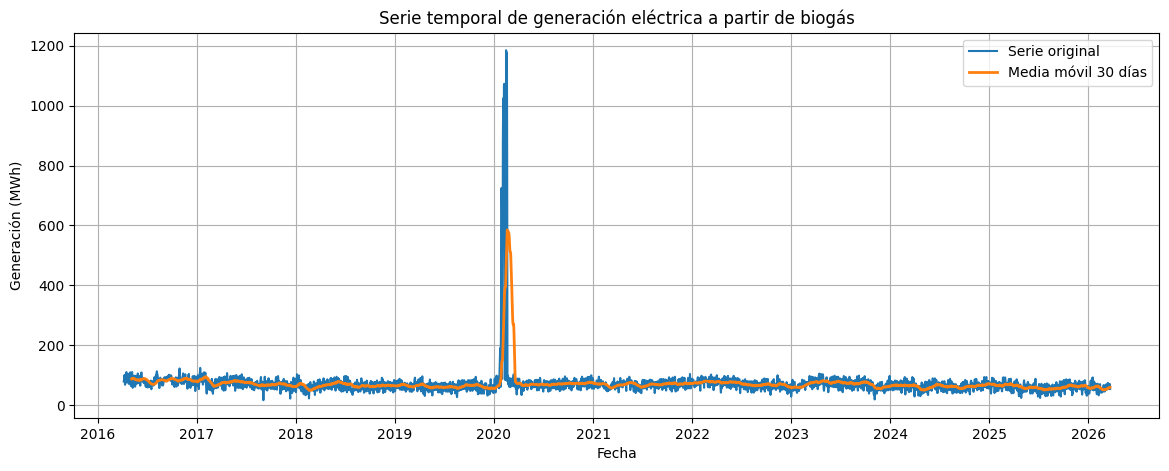

In [ ]:
# Importar función del test Dickey-Fuller aumentado
from statsmodels.tsa.stattools import adfuller
# Permite evaluar estadísticamente la estacionariedad de la serie temporal

# Crear figura para visualizar la serie temporal
plt.figure(figsize=(14, 5))

# Representar la serie origina con  la evolución temporal de la generación de biogás
plt.plot(df_model["datetime"], serie, label="Serie original")


# Calcular media móvil de 30 días
rolling_mean = pd.Series(serie).rolling(window=30).mean() # Suaviza fluctuaciones de corto plazo para observar tendencia general

# Representar media móvil en visualización
plt.plot(df_model["datetime"], rolling_mean, label="Media móvil 30 días", linewidth=2)

# Añadir título
plt.title("Serie temporal de generación eléctrica a partir de biogás")
# Título descriptivo del gráfico

# Añadir etiqueta eje X
plt.xlabel("Fecha")
# Etiqueta temporal

# Añadir etiqueta eje Y
plt.ylabel("Generación (MWh)")
# Unidad de medida de la serie

# Mostrar leyenda
plt.legend()
# Identifica cada línea representada

# Mostrar gráfico
plt.show()
# Renderiza la figura

**Aplicación del test Dickey-Fuller aumentado (ADF)**

A continuación, se aplica formalmente el test ADF sobre la serie original. El objetivo es determinar si la serie puede considerarse estacionaria o si requiere diferenciación antes del ajuste del modelo SARIMA.
Se mostrarán:
el estadístico del test,
el \emph{p-value},
y los valores críticos para distintos niveles de significación.
La interpretación principal se basa en el \emph{p-value}:
Si p<0.05, se rechaza la hipótesis nula y la serie puede considerarse estacionaria.
Si p≥0.05, no puede rechazarse la hipótesis de no estacionariedad y será necesario aplicar diferenciación.

In [ ]:
# Aplicar el test Dickey-Fuller aumentado sobre la serie original
adf_result = adfuller(serie)
# Evalúa si la serie presenta raíz unitaria (no estacionariedad)

# Mostrar estadístico del test
print("ADF Statistic:", adf_result[0])
# Cuanto más negativo, mayor evidencia de estacionariedad

# Mostrar p-value
print("p-value:", adf_result[1])
# Permite decidir si se rechaza la hipótesis nula

# Mostrar número de retardos utilizados
print("Número de retardos utilizados:", adf_result[2])
# Número de lags empleados automáticamente en el test

# Mostrar número de observaciones utilizadas
print("Número de observaciones:", adf_result[3])
# Tamaño efectivo de muestra tras aplicar retardos

# Mostrar valores críticos
print("\nValores críticos:")
# Referencias para distintos niveles de significación

# Recorrer valores críticos
for key, value in adf_result[4].items():
    print(f"{key}: {value}")
    # Imprime valores críticos al 1%, 5% y 10%

# Interpretación automática del resultado
if adf_result[1] < 0.05:
    print("\nLa serie puede considerarse estacionaria (p < 0.05).")
else:
    print("\nLa serie NO es estacionaria (p >= 0.05).")

ADF Statistic: -7.692994006054594
p-value: 1.4030699372304155e-11
Número de retardos utilizados: 30
Número de observaciones: 3607

Valores críticos:
1%: -3.4321642389337907
5%: -2.862341629305848
10%: -2.5671967199233476

La serie puede considerarse estacionaria (p < 0.05).


**División cronológica en train, validation y test**

En esta celda se divide la serie en entrenamiento, validación y test, respetando el orden temporal. Se mantienen las mismas proporciones utilizadas en los modelos RNN, LSTM y GRU: 70% para entrenamiento, 15% para validación y 15% para test. El conjunto de validación se utilizará para seleccionar la mejor configuración SARIMA y el conjunto de test quedará reservado para la evaluación final.

In [ ]:
# Definir proporción destinada a entrenamiento
train_ratio = 0.70  # El 70% inicial de la serie se usa para entrenar

# Definir proporción destinada a validación
val_ratio = 0.15  # El siguiente 15% se usa para seleccionar la configuración

# Definir proporción destinada a test
test_ratio = 0.15  # El último 15% se reserva para evaluación final

# Calcular el número total de observaciones
n_total = len(serie)  # Obtiene la longitud completa de la serie

# Calcular el punto de corte entre train y validation
train_end = int(n_total * train_ratio)  # Índice final del conjunto de entrenamiento

# Calcular el punto de corte entre validation y test
val_end = int(n_total * (train_ratio + val_ratio))  # Índice final del conjunto de validación

# Crear conjunto de entrenamiento
train = serie[:train_end]  # Primer tramo temporal de la serie

# Crear conjunto de validación
val = serie[train_end:val_end]  # Tramo temporal posterior al entrenamiento

# Crear conjunto de test
test = serie[val_end:]  # Tramo final reservado para evaluación fuera de muestra

# Crear fechas de entrenamiento
train_dates = df_model["datetime"].iloc[:train_end]  # Fechas asociadas al conjunto train

# Crear fechas de validación
val_dates = df_model["datetime"].iloc[train_end:val_end]  # Fechas asociadas al conjunto validation

# Crear fechas de test
test_dates = df_model["datetime"].iloc[val_end:]  # Fechas asociadas al conjunto test

# Mostrar tamaño del conjunto de entrenamiento
print("Tamaño train:", len(train))  # Comprueba número de observaciones en train

# Mostrar tamaño del conjunto de validación
print("Tamaño validation:", len(val))  # Comprueba número de observaciones en validation

# Mostrar tamaño del conjunto de test
print("Tamaño test:", len(test))  # Comprueba número de observaciones en test

Tamaño train: 2546
Tamaño validation: 546
Tamaño test: 546


**Definición de la grilla SARIMA**

En este bloque se define una grilla pequeña y razonable. Se incluye una componente estacional semanal con periodo 7, porque la serie mostró estructura semanal en el análisis exploratorio. Además, se evita d=2, ya que en el ARIMA anterior generó una predicción poco realista y demasiado descendente. Esta grilla tiene pocas combinaciones, el objetivo es contsruir un baseline estadístico razonable que incorpore la estructura semanal detectada, sin disparar el coste computacional.

In [ ]:
# Definir posibles valores del parámetro p
p_values = [0, 1, 2]  # Número de términos autorregresivos no estacionales

# Definir posibles valores del parámetro d
d_values = [0, 1]  # Se evita d=2 para no sobrediferenciar la serie

# Definir posibles valores del parámetro q
q_values = [0, 1, 2]  # Número de términos de media móvil no estacionales

# Definir combinaciones estacionales candidatas
seasonal_orders = [
    (0, 0, 0, 7),  # Modelo sin componente estacional explícita
    (1, 0, 0, 7),  # Componente autorregresiva semanal
    (0, 0, 1, 7),  # Componente de media móvil semanal
    (1, 0, 1, 7)   # Componente estacional semanal simple y completa
]  # Se prueban solo estructuras semanales sencillas

# Construir todas las combinaciones SARIMA
sarima_combinations = list(product(
    p_values,  # Valores posibles de p
    d_values,  # Valores posibles de d
    q_values,  # Valores posibles de q
    seasonal_orders  # Órdenes estacionales semanales candidatas
))

# Mostrar número total de combinaciones
print("Número total de combinaciones SARIMA:", len(sarima_combinations))  # Comprueba el tamaño de la grilla

Número total de combinaciones SARIMA: 72


**Definición de una validación reducida para acelerar la búsqueda**

Para seleccionar la mejor configuración sin que el notebook tarde horas, la búsqueda se realiza sobre una parte reciente del conjunto de validación. En lugar de evaluar cada modelo sobre los 546 días de validación, se usan los últimos 180 días. Esto reduce mucho el tiempo de ejecución y permite seleccionar una configuración razonable. Después, el modelo elegido sí se evaluará sobre la validación completa y el test completo.

In [ ]:
# Definir número de días de validación usados para la búsqueda
n_val_search = 180  # Se usan los últimos 180 días de validation para acelerar la selección

# Crear historial para la búsqueda
train_search = np.concatenate([train, val[:-n_val_search]])  # Usa train y la parte inicial de validation como historial

# Crear tramo de validación reducido
val_search = val[-n_val_search:]  # Usa los últimos 180 días de validation para comparar modelos

# Mostrar tamaño del historial de búsqueda
print("Tamaño train_search:", len(train_search))  # Comprueba cuántas observaciones usa el modelo como histórico

# Mostrar tamaño del tramo de validación reducido
print("Tamaño val_search:", len(val_search))  # Comprueba cuántas observaciones se usan para seleccionar hiperparámetros

Tamaño train_search: 2912
Tamaño val_search: 180


**Función de predicción rolling a un paso**

Esta función realiza predicción rolling a un paso adelante. La idea es que el modelo predice el siguiente día, después incorpora el valor real observado y continúa con el día siguiente. Esto es importante porque tu problema está formulado como predicción t+1, igual que en los modelos RNN, LSTM y GRU. Además, se usa append(..., refit=False), que actualiza el modelo con nuevos datos sin reentrenarlo desde cero en cada paso, reduciendo mucho el tiempo de ejecución.

In [ ]:
# Definir función de predicción rolling SARIMA
def prediccion_rolling_sarima(train_series, future_series, order, seasonal_order):  # Recibe histórico, futuro y parámetros SARIMA

    # Crear modelo SARIMA inicial
    model = SARIMAX(
        np.asarray(train_series),  # Convierte el histórico a array para evitar problemas de índice
        order=order,  # Define el orden no estacional del modelo
        seasonal_order=seasonal_order,  # Define el orden estacional semanal del modelo
        enforce_stationarity=False,  # Relaja la restricción de estacionariedad para evitar fallos de ajuste
        enforce_invertibility=False  # Relaja la restricción de invertibilidad para facilitar la estimación
    )

    # Ajustar el modelo inicial
    model_fit = model.fit(disp=False, maxiter=50)  # Ajusta el modelo limitando iteraciones para acelerar el proceso

    # Crear lista vacía para almacenar predicciones
    predictions = []  # Aquí se guardarán las predicciones paso a paso

    # Guardar el modelo ajustado como estado actual
    current_fit = model_fit  # Este objeto se irá actualizando con los valores reales observados

    # Recorrer cada observación futura
    for t in range(len(future_series)):  # Itera sobre validation o test

        # Generar predicción a un paso
        pred = np.asarray(current_fit.forecast(steps=1))[0]  # Predice solo el siguiente valor y lo extrae como número

        # Guardar predicción
        predictions.append(pred)  # Añade la predicción a la lista

        # Actualizar el modelo con el valor real observado
        current_fit = current_fit.append(endog=[future_series[t]], refit=False)  # Incorpora el dato real sin reestimar parámetros

    # Convertir predicciones a array
    predictions = np.array(predictions)  # Convierte la lista de predicciones en array NumPy

    # Devolver predicciones
    return predictions  # Devuelve las predicciones generadas

**Función para evaluar una configuración SARIMA**

Esta función evalúa una configuración SARIMA concreta usando el tramo reducido de validación. Para cada combinación, genera predicciones rolling y calcula MAE y RMSE en MWh. Estas métricas son las mismas que se han utilizado en los modelos de deep learning, por lo que el criterio de selección sigue siendo comparable.

In [ ]:
# Definir función para evaluar una combinación SARIMA
def evaluar_sarima(params):  # Recibe una combinación de hiperparámetros

    # Extraer parámetros no estacionales y estacionales
    p, d, q, seasonal_order = params  # La combinación incluye p, d, q y seasonal_order

    # Definir orden no estacional
    order = (p, d, q)  # Construye la tupla ARIMA no estacional

    # Intentar ajustar y evaluar el modelo
    try:  # Permite continuar aunque una combinación concreta falle

        # Generar predicciones rolling sobre validación reducida
        y_val_pred = prediccion_rolling_sarima(
            train_series=train_search,  # Historial utilizado para seleccionar hiperparámetros
            future_series=val_search,  # Tramo reducido de validación
            order=order,  # Orden no estacional
            seasonal_order=seasonal_order  # Orden estacional semanal
        )

        # Definir valores reales de validación reducida
        y_val_real = val_search  # Valores reales contra los que se evalúa

        # Calcular MAE de validación
        mae_val = mean_absolute_error(y_val_real, y_val_pred)  # Error absoluto medio en MWh

        # Calcular RMSE de validación
        rmse_val = np.sqrt(mean_squared_error(y_val_real, y_val_pred))  # Raíz del error cuadrático medio en MWh

        # Devolver resultados de la combinación
        return {
            "order": order,  # Orden no estacional
            "seasonal_order": seasonal_order,  # Orden estacional semanal
            "p": p,  # Parámetro p
            "d": d,  # Parámetro d
            "q": q,  # Parámetro q
            "val_mae": mae_val,  # MAE sobre validación reducida
            "val_rmse": rmse_val  # RMSE sobre validación reducida
        }

    # Capturar errores de ajuste
    except Exception as e:  # Si una combinación falla, se registra y se omite

        # Mostrar combinación fallida
        print(f"Fallo en SARIMA{order}x{seasonal_order}: {e}")  # Permite diagnosticar errores sin detener el notebook

        # Devolver None si falla
        return None  # Evita que una combinación fallida interrumpa la búsqueda

**Ejecución de la búsqueda SARIMA**

En esta celda se ejecuta la búsqueda sobre la grilla reducida. El número de combinaciones es pequeño, y además cada combinación se evalúa sobre una validación reducida, por lo que el tiempo de ejecución debería ser razonable. El resultado será una lista de modelos evaluados con sus métricas de validación.

In [ ]:
# Crear lista vacía para almacenar resultados
results = []  # Guardará los resultados de las combinaciones SARIMA evaluadas

# Recorrer todas las combinaciones SARIMA
for i, params in enumerate(sarima_combinations, start=1):  # Itera sobre la grilla reducida

    # Mostrar progreso de la búsqueda
    print(f"Probando combinación {i}/{len(sarima_combinations)} -> SARIMA{params}")  # Informa del avance del proceso

    # Evaluar combinación actual
    resultado = evaluar_sarima(params)  # Ajusta y evalúa la configuración actual

    # Comprobar si la combinación ha generado un resultado válido
    if resultado is not None:  # Solo guarda modelos que se han ajustado correctamente

        # Guardar resultado obtenido
        results.append(resultado)  # Añade el resultado válido a la lista

# Mostrar número de modelos ajustados correctamente
print("\nNúmero total de modelos SARIMA ajustados correctamente:", len(results))  # Resume cuántos modelos han sido válidos

Probando combinación 1/72 -> SARIMA(0, 0, 0, (0, 0, 0, 7))
Probando combinación 2/72 -> SARIMA(0, 0, 0, (1, 0, 0, 7))
Probando combinación 3/72 -> SARIMA(0, 0, 0, (0, 0, 1, 7))
Probando combinación 4/72 -> SARIMA(0, 0, 0, (1, 0, 1, 7))
Probando combinación 5/72 -> SARIMA(0, 0, 1, (0, 0, 0, 7))
Probando combinación 6/72 -> SARIMA(0, 0, 1, (1, 0, 0, 7))
Probando combinación 7/72 -> SARIMA(0, 0, 1, (0, 0, 1, 7))
Probando combinación 8/72 -> SARIMA(0, 0, 1, (1, 0, 1, 7))
Probando combinación 9/72 -> SARIMA(0, 0, 2, (0, 0, 0, 7))
Probando combinación 10/72 -> SARIMA(0, 0, 2, (1, 0, 0, 7))
Probando combinación 11/72 -> SARIMA(0, 0, 2, (0, 0, 1, 7))
Probando combinación 12/72 -> SARIMA(0, 0, 2, (1, 0, 1, 7))
Probando combinación 13/72 -> SARIMA(0, 1, 0, (0, 0, 0, 7))
Probando combinación 14/72 -> SARIMA(0, 1, 0, (1, 0, 0, 7))
Probando combinación 15/72 -> SARIMA(0, 1, 0, (0, 0, 1, 7))
Probando combinación 16/72 -> SARIMA(0, 1, 0, (1, 0, 1, 7))
Probando combinación 17/72 -> SARIMA(0, 1, 1, (0,

**Selección del mejor modelo SARIMA**

Una vez evaluadas las configuraciones, se construye una tabla con los resultados y se ordena por MAE de validación. La mejor configuración será la que minimice este error, manteniendo el mismo criterio que en los modelos de deep learning.

In [ ]:
# Convertir la lista de resultados en DataFrame
results_df = pd.DataFrame(results)  # Cada fila representa una configuración SARIMA evaluada

# Ordenar resultados por MAE de validación
results_df_sin_modelo = results_df.sort_values(by="val_mae", ascending=True)  # Ordena de menor a mayor error

# Resetear índice después de ordenar
results_df_sin_modelo = results_df_sin_modelo.reset_index(drop=True)  # Limpia el índice de la tabla

# Extraer las cinco mejores combinaciones
top5_sarima = results_df_sin_modelo.head(5)  # Selecciona los cinco mejores modelos

# Mostrar tabla top 5
print("Top 5 combinaciones de hiperparámetros para SARIMA:\n")  # Título informativo

# Imprimir top 5
print(top5_sarima)  # Muestra las cinco mejores configuraciones

Top 5 combinaciones de hiperparámetros para SARIMA:

       order seasonal_order  p  d  q   val_mae  val_rmse
0  (1, 0, 0)   (1, 0, 1, 7)  1  0  0  6.497380  8.350464
1  (2, 0, 0)   (1, 0, 1, 7)  2  0  0  7.109467  9.128244
2  (1, 0, 1)   (1, 0, 1, 7)  1  0  1  7.325828  9.280038
3  (2, 0, 1)   (1, 0, 1, 7)  2  0  1  7.372421  9.372117
4  (1, 0, 2)   (1, 0, 1, 7)  1  0  2  7.523629  9.616925


**Recuperación de la mejor configuración**

En este bloque se recupera la mejor combinación SARIMA encontrada. Se guardan tanto el orden no estacional como el orden estacional, porque ambos definen la estructura final del modelo.

In [ ]:
# Recuperar la mejor combinación de hiperparámetros
best_params = top5_sarima.iloc[0]  # Selecciona la primera fila de la tabla ordenada

# Mostrar mejor combinación encontrada
print("Mejor combinación encontrada para SARIMA:\n")  # Título informativo

# Imprimir mejores parámetros
print(best_params)  # Muestra los parámetros y métricas de la mejor configuración

# Extraer mejor orden no estacional
best_order = best_params["order"]  # Guarda el orden ARIMA seleccionado

# Extraer mejor orden estacional
best_seasonal_order = best_params["seasonal_order"]  # Guarda el orden estacional semanal seleccionado

# Mostrar mejor orden no estacional
print("\nMejor orden ARIMA:", best_order)  # Imprime el orden no estacional

# Mostrar mejor orden estacional
print("Mejor orden estacional:", best_seasonal_order)  # Imprime el orden estacional

Mejor combinación encontrada para SARIMA:

order                (1, 0, 0)
seasonal_order    (1, 0, 1, 7)
p                            1
d                            0
q                            0
val_mae                6.49738
val_rmse              8.350464
Name: 0, dtype: object

Mejor orden ARIMA: (1, 0, 0)
Mejor orden estacional: (1, 0, 1, 7)


**Predicciones finales sobre validation y test**

Una vez seleccionada la mejor configuración, se evalúa el modelo sobre la validación completa y sobre el test completo. Para validation se usa como historial inicial el conjunto de entrenamiento. Para test se usa como historial todo lo disponible antes del test, es decir, train + validation. Esto es equivalente a lo que se hace en una situación real: se usa toda la información histórica disponible antes de predecir el periodo final.

In [ ]:
# Generar predicciones rolling sobre validation completa
y_val_pred = prediccion_rolling_sarima(
    train_series=train,  # Historial inicial para validation
    future_series=val,  # Conjunto completo de validación
    order=best_order,  # Mejor orden no estacional
    seasonal_order=best_seasonal_order  # Mejor orden estacional
)

# Definir valores reales de validation
y_val_real = val  # Valores reales observados en validación

# Crear conjunto train + validation
train_val = np.concatenate([train, val])  # Historial disponible antes del conjunto test

# Generar predicciones rolling sobre test completo
y_test_pred = prediccion_rolling_sarima(
    train_series=train_val,  # Historial completo disponible antes de test
    future_series=test,  # Conjunto completo de test
    order=best_order,  # Mejor orden no estacional
    seasonal_order=best_seasonal_order  # Mejor orden estacional
)

# Definir valores reales de test
y_test_real = test  # Valores reales observados en test

**Cálculo de métricas finales**

En esta celda se calculan las métricas finales del modelo SARIMA en validación y test. Se utilizan MAE y RMSE en MWh, igual que en todos los modelos anteriores, lo que permite comparar directamente el rendimiento del baseline estadístico frente a RNN, LSTM y GRU.

In [ ]:
# Calcular MAE en validation
mae_val_final = mean_absolute_error(y_val_real, y_val_pred)  # Error absoluto medio en validación

# Calcular RMSE en validation
rmse_val_final = np.sqrt(mean_squared_error(y_val_real, y_val_pred))  # Raíz del error cuadrático medio en validación

# Calcular MAE en test
mae_test_final = mean_absolute_error(y_test_real, y_test_pred)  # Error absoluto medio en test

# Calcular RMSE en test
rmse_test_final = np.sqrt(mean_squared_error(y_test_real, y_test_pred))  # Raíz del error cuadrático medio en test

# Mostrar título de resultados
print("Resultados finales del modelo SARIMA rolling")  # Identifica el bloque de resultados

# Mostrar mejor orden no estacional
print(f"Mejor orden ARIMA: {best_order}")  # Muestra la estructura no estacional seleccionada

# Mostrar mejor orden estacional
print(f"Mejor orden estacional: {best_seasonal_order}")  # Muestra la estructura estacional seleccionada

# Mostrar MAE de validation
print(f"MAE validation:  {mae_val_final:.3f} MWh")  # Imprime MAE en validación

# Mostrar RMSE de validation
print(f"RMSE validation: {rmse_val_final:.3f} MWh")  # Imprime RMSE en validación

# Mostrar MAE de test
print(f"MAE test:        {mae_test_final:.3f} MWh")  # Imprime MAE en test

# Mostrar RMSE de test
print(f"RMSE test:       {rmse_test_final:.3f} MWh")  # Imprime RMSE en test

Resultados finales del modelo SARIMA rolling
Mejor orden ARIMA: (1, 0, 0)
Mejor orden estacional: (1, 0, 1, 7)
MAE validation:  6.225 MWh
RMSE validation: 8.115 MWh
MAE test:        6.136 MWh
RMSE test:       7.944 MWh


**Cálculo de métricas en el conjunto de entrenamiento**

Para completar el análisis dentro y fuera de muestra, se calculan también las métricas en el conjunto de entrenamiento. Se utiliza el mismo modelo SARIMA seleccionado y la misma lógica de predicción rolling un paso adelante: el modelo predice cada día del histórico utilizando solo la información anterior, lo que mantiene la comparabilidad con validation y test.

In [ ]:
# Definir tamaño del histórico inicial para predicción rolling sobre train
n_init = 365  # Se usa el primer año como histórico inicial para tener suficiente memoria estacional

# Crear histórico inicial
train_init = train[:n_init]  # Primer tramo del entrenamiento que se utiliza como historial

# Crear tramo de train a predecir
train_to_predict = train[n_init:]  # Resto del entrenamiento sobre el que se aplicará la predicción rolling

# Generar predicciones rolling sobre el tramo de entrenamiento
y_train_pred_sarima = prediccion_rolling_sarima(
    train_series=train_init,           # Historial inicial
    future_series=train_to_predict,    # Tramo a predecir un paso adelante
    order=best_order,                  # Mejor orden no estacional
    seasonal_order=best_seasonal_order # Mejor orden estacional
)

# Definir valores reales del tramo de train predicho
y_train_real_sarima = train_to_predict  # Valores reales correspondientes al tramo evaluado

# Calcular MAE en train
mae_train_final = mean_absolute_error(y_train_real_sarima, y_train_pred_sarima)  # Error absoluto medio en train

# Calcular RMSE en train
rmse_train_final = np.sqrt(mean_squared_error(y_train_real_sarima, y_train_pred_sarima))  # Raíz del error cuadrático medio en train

# Mostrar título de resultados
print("Métricas del modelo SARIMA en train")

# Mostrar MAE de train
print(f"MAE train:  {mae_train_final:.3f} MWh")

# Mostrar RMSE de train
print(f"RMSE train: {rmse_train_final:.3f} MWh")

Métricas del modelo SARIMA en train
MAE train:  10.874 MWh
RMSE train: 38.428 MWh


**Comparación gráfica en test**

Este bloque representa los valores reales y predichos por SARIMA en el conjunto de test. El objetivo es comprobar visualmente si el modelo sigue la dinámica general de la serie y si mejora el comportamiento del ARIMA anterior, que generaba una predicción demasiado plana y poco ajustada.

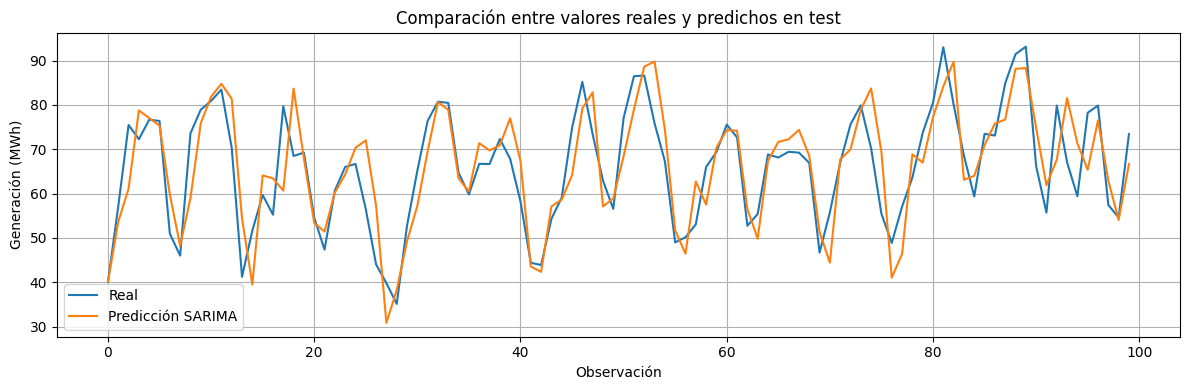

In [ ]:
# Definir número de observaciones a mostrar
n_mostrar = 100  # Número de observaciones del test que se representarán

# Crear figura
plt.figure(figsize=(12, 4))  # Define tamaño del gráfico

# Representar valores reales del test
plt.plot(y_test_real[:n_mostrar], label="Real")  # Dibuja la serie observada

# Representar predicciones SARIMA del test
plt.plot(y_test_pred[:n_mostrar], label="Predicción SARIMA")  # Dibuja la serie predicha

# Añadir título
plt.title("Comparación entre valores reales y predichos en test")  # Título del gráfico

# Añadir etiqueta eje X
plt.xlabel("Observación")  # Identifica las observaciones del test

# Añadir etiqueta eje Y
plt.ylabel("Generación (MWh)")  # Identifica la unidad de generación

# Añadir leyenda
plt.legend()  # Muestra la leyenda

# Ajustar diseño
plt.tight_layout()  # Ajusta los márgenes del gráfico

# Mostrar gráfico
plt.show()  # Renderiza la figura

**Tabla resumen del top 5**

Esta tabla permite documentar la fase de selección del modelo SARIMA. No es necesario que SARIMA supere a las redes neuronales; su función dentro del TFG es actuar como baseline estadístico razonable. Por eso resulta útil mostrar qué configuraciones se evaluaron y cuál fue la seleccionada.

In [ ]:
# Crear copia del top 5
tabla_top5_sarima = top5_sarima.copy()  # Copia independiente para formatear la tabla

# Redondear MAE
tabla_top5_sarima["val_mae"] = tabla_top5_sarima["val_mae"].round(3)  # Redondea MAE a tres decimales

# Redondear RMSE
tabla_top5_sarima["val_rmse"] = tabla_top5_sarima["val_rmse"].round(3)  # Redondea RMSE a tres decimales

# Renombrar columnas para presentación
tabla_top5_sarima = tabla_top5_sarima.rename(columns={
    "order": "Order",  # Orden no estacional
    "seasonal_order": "Seasonal order",  # Orden estacional
    "val_mae": "Validation MAE",  # MAE de validación
    "val_rmse": "Validation RMSE"  # RMSE de validación
})

# Mostrar título de la tabla
print("Tabla resumen con las 5 mejores combinaciones de hiperparámetros para SARIMA:\n")  # Título informativo

# Mostrar tabla
print(tabla_top5_sarima)  # Imprime la tabla resumen

# Mostrar tabla como DataFrame
tabla_top5_sarima  # Permite visualizar la tabla con formato en Colab

Tabla resumen con las 5 mejores combinaciones de hiperparámetros para SARIMA:

       Order Seasonal order  p  d  q  Validation MAE  Validation RMSE
0  (1, 0, 0)   (1, 0, 1, 7)  1  0  0           6.497            8.350
1  (2, 0, 0)   (1, 0, 1, 7)  2  0  0           7.109            9.128
2  (1, 0, 1)   (1, 0, 1, 7)  1  0  1           7.326            9.280
3  (2, 0, 1)   (1, 0, 1, 7)  2  0  1           7.372            9.372
4  (1, 0, 2)   (1, 0, 1, 7)  1  0  2           7.524            9.617


,Order,Seasonal order,p,d,q,Validation MAE,Validation RMSE
0,"(1, 0, 0)","(1, 0, 1, 7)",1,0,0,6.497,8.350
1,"(2, 0, 0)","(1, 0, 1, 7)",2,0,0,7.109,9.128
2,"(1, 0, 1)","(1, 0, 1, 7)",1,0,1,7.326,9.280
3,"(2, 0, 1)","(1, 0, 1, 7)",2,0,1,7.372,9.372
4,"(1, 0, 2)","(1, 0, 1, 7)",1,0,2,7.524,9.617


**Gráfico amplio de validation y test**

Este último gráfico permite observar de forma conjunta el comportamiento del modelo en validación y test. Es útil para comprobar si la predicción mantiene una dinámica razonable en ambos periodos y para compararlo visualmente con las gráficas generadas para RNN, LSTM y GRU.

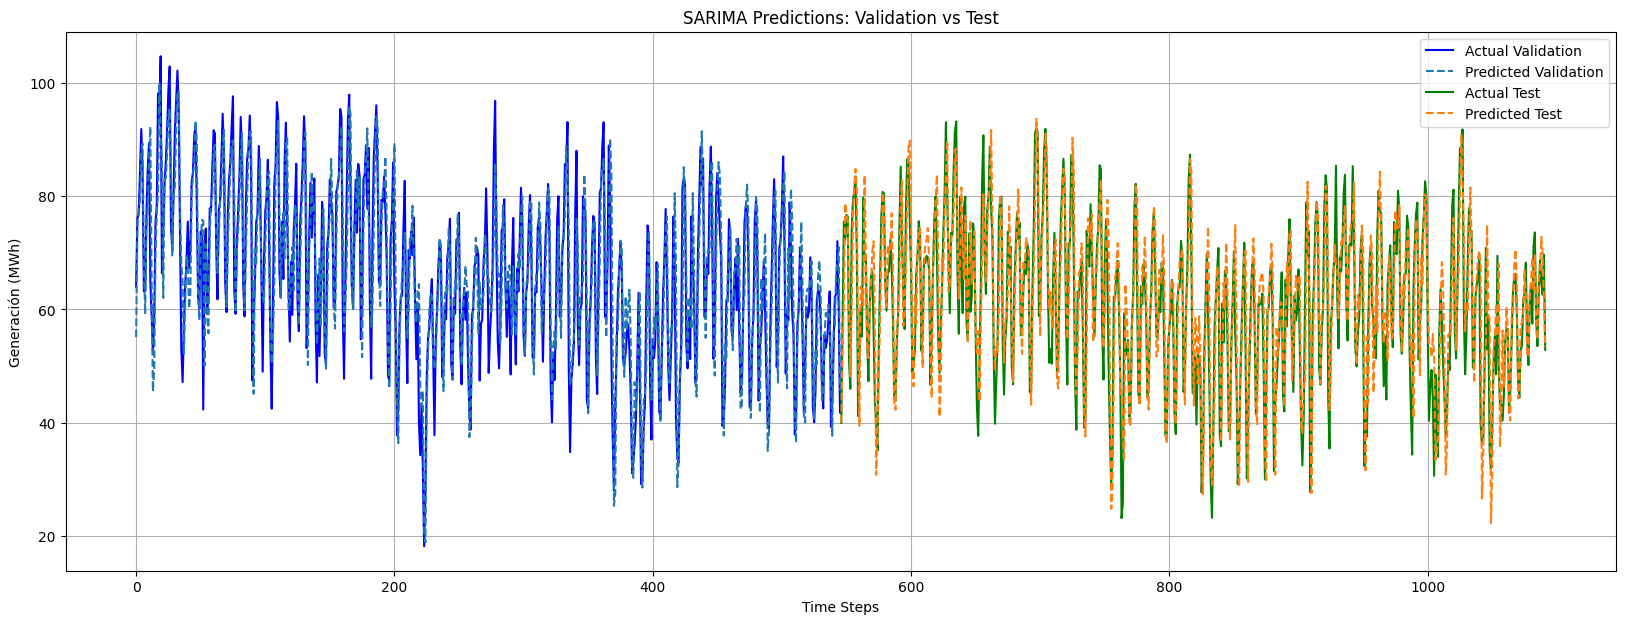

In [ ]:
# Crear eje temporal para validation
val_time_steps = range(len(y_val_real))  # Índices temporales del conjunto validation

# Crear eje temporal para test como continuación de validation
test_time_steps = range(len(y_val_real), len(y_val_real) + len(y_test_real))  # Índices temporales del conjunto test

# Crear figura grande
plt.figure(figsize=(20, 7))  # Define tamaño amplio para visualizar ambos periodos

# Representar valores reales de validation
plt.plot(val_time_steps, y_val_real, label="Actual Validation", color="blue")  # Dibuja la serie real de validation

# Representar predicciones de validation
plt.plot(val_time_steps, y_val_pred, label="Predicted Validation", linestyle="--")  # Dibuja predicciones de validation

# Representar valores reales de test
plt.plot(test_time_steps, y_test_real, label="Actual Test", color="green")  # Dibuja la serie real de test

# Representar predicciones de test
plt.plot(test_time_steps, y_test_pred, label="Predicted Test", linestyle="--")  # Dibuja predicciones de test

# Añadir título
plt.title("SARIMA Predictions: Validation vs Test")  # Título del gráfico

# Añadir etiqueta eje X
plt.xlabel("Time Steps")  # Etiqueta del eje horizontal

# Añadir etiqueta eje Y
plt.ylabel("Generación (MWh)")  # Etiqueta del eje vertical

# Añadir leyenda
plt.legend()  # Muestra la leyenda

# Activar cuadrícula
plt.grid(True)  # Facilita la lectura visual

# Mostrar gráfico
plt.show()  # Renderiza la figura


**Evolución del error del modelo**

En este bloque final se analiza la evolución temporal del error absoluto del modelo SARIMA en los tres conjuntos. El error en train se calcula utilizando las predicciones rolling generadas en el bloque anterior sobre el tramo correspondiente del entrenamiento, mientras que los errores en validation y test proceden de las predicciones ya disponibles. El primer gráfico representa el error absoluto día a día, junto con las líneas horizontales que indican el MAE medio en cada conjunto. El segundo gráfico complementa el análisis con un boxplot que resume la distribución de los errores y permite detectar diferencias sistemáticas entre las tres particiones.

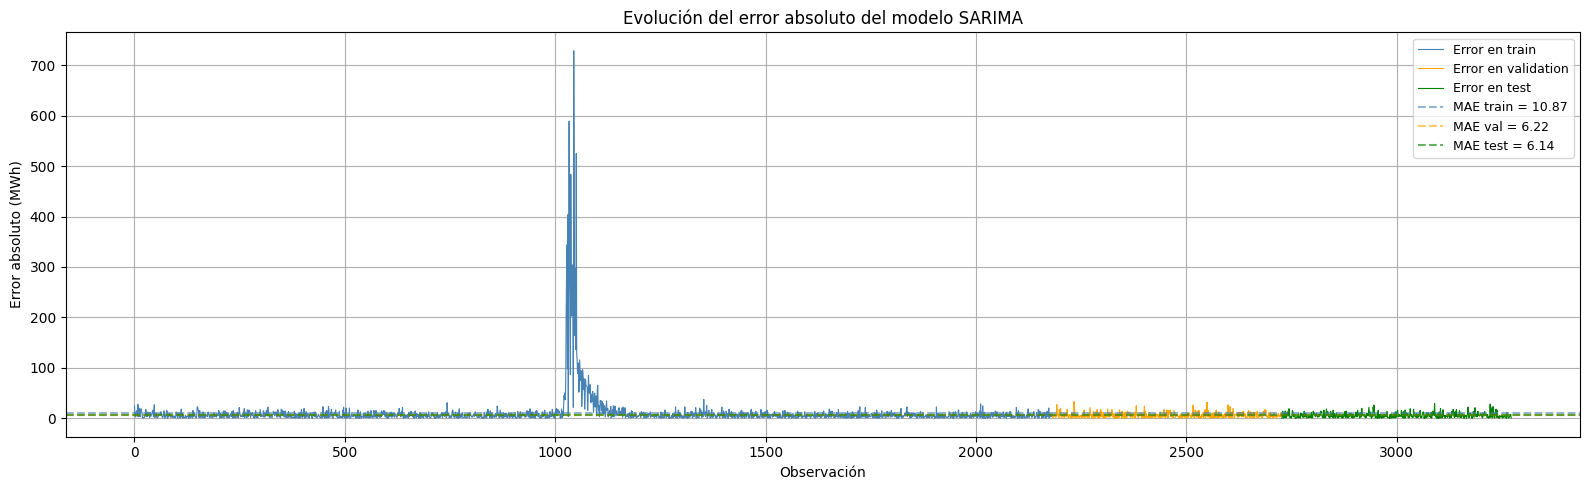

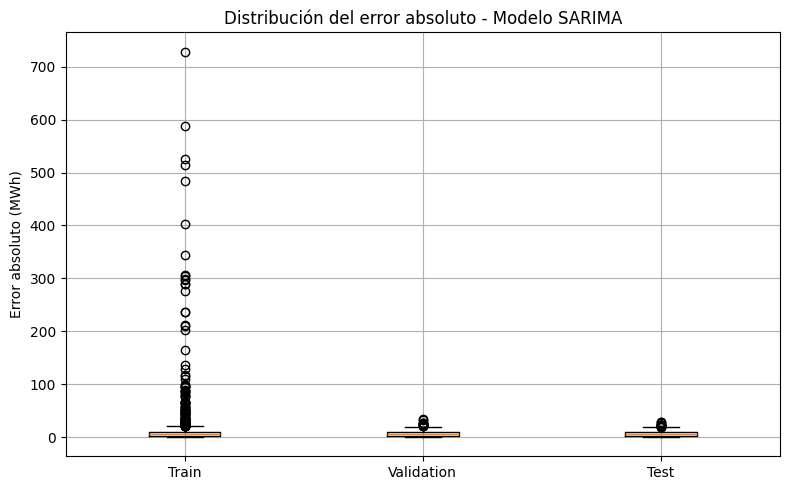

In [ ]:
# Calcular el error absoluto en train
err_train = np.abs(np.asarray(y_train_real_sarima) - np.asarray(y_train_pred_sarima))  # Error absoluto día a día en train

# Calcular el error absoluto en validation
err_val = np.abs(np.asarray(y_val_real) - np.asarray(y_val_pred))  # Error absoluto día a día en validation

# Calcular el error absoluto en test
err_test = np.abs(np.asarray(y_test_real) - np.asarray(y_test_pred))  # Error absoluto día a día en test

# Crear ejes temporales encadenados
x_train = np.arange(len(err_train))
x_val = np.arange(len(err_train), len(err_train) + len(err_val))
x_test = np.arange(len(err_train) + len(err_val),
                   len(err_train) + len(err_val) + len(err_test))

# Crear figura para la evolución temporal del error
plt.figure(figsize=(16, 5))

# Representar error absoluto en train
plt.plot(x_train, err_train, label="Error en train", color="steelblue", linewidth=0.8)

# Representar error absoluto en validation
plt.plot(x_val, err_val, label="Error en validation", color="orange", linewidth=0.8)

# Representar error absoluto en test
plt.plot(x_test, err_test, label="Error en test", color="green", linewidth=0.8)

# Añadir líneas horizontales con el MAE medio
plt.axhline(mae_train_final, color="steelblue", linestyle="--", alpha=0.6, label=f"MAE train = {mae_train_final:.2f}")
plt.axhline(mae_val_final, color="orange", linestyle="--", alpha=0.6, label=f"MAE val = {mae_val_final:.2f}")
plt.axhline(mae_test_final, color="green", linestyle="--", alpha=0.6, label=f"MAE test = {mae_test_final:.2f}")

# Añadir título y etiquetas
plt.title("Evolución del error absoluto del modelo SARIMA")
plt.xlabel("Observación")
plt.ylabel("Error absoluto (MWh)")
plt.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

# Crear figura para el boxplot
plt.figure(figsize=(8, 5))

# Construir lista con los tres arrays de error
errores = [err_train, err_val, err_test]

# Representar boxplot
plt.boxplot(errores, labels=["Train", "Validation", "Test"], showfliers=True)

# Añadir título y etiquetas
plt.title("Distribución del error absoluto - Modelo SARIMA")
plt.ylabel("Error absoluto (MWh)")
plt.tight_layout()
plt.show()